In [28]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

import torchvision
import torchvision.transforms as transforms
from torchvision import datasets, models

from sklearn.metrics import confusion_matrix, classification_report, precision_score, f1_score



In [29]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rambhadrakumar","key":"3802cabd2ec9aec83dabcac171bc5da6"}'}

In [5]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)

In [6]:
!kaggle datasets download -d alessiocorrado99/animals10 -p /content/ --unzip

Dataset URL: https://www.kaggle.com/datasets/alessiocorrado99/animals10
License(s): GPL-2.0
100% 586M/586M [00:27<00:00, 22.2MB/s]



In [7]:
DATA_DIR = '/content/raw-img'
print(os.listdir(DATA_DIR))

['pecora', 'gallina', 'cavallo', 'elefante', 'cane', 'farfalla', 'gatto', 'scoiattolo', 'ragno', 'mucca']


In [30]:
import shutil, uuid

rename_map = {
    'cane': 'dog', 'cavallo': 'horse', 'elefante': 'elephant',
    'farfalla': 'butterfly', 'gallina': 'chicken', 'gatto': 'cat',
    'mucca': 'cow', 'pecora': 'sheep', 'ragno': 'spider', 'scoiattolo': 'squirrel'
}

for italian, english in rename_map.items():
    old_path = os.path.join(DATA_DIR, italian)
    new_path = os.path.join(DATA_DIR, english)

    if os.path.exists(old_path) and os.path.exists(new_path):
        for file in os.listdir(old_path):
            src = os.path.join(old_path, file)
            dst = os.path.join(new_path, file)

            if os.path.exists(dst):
                name, ext = os.path.splitext(file)
                dst = os.path.join(new_path, f"{name}_{uuid.uuid4().hex[:6]}{ext}")
            shutil.move(src, dst)
        os.rmdir(old_path)
        print(f"Merged: {italian} → {english}")

    elif os.path.exists(old_path):
        os.rename(old_path, new_path)
        print(f"Renamed: {italian} → {english}")

print("\nFinal folders:", sorted(os.listdir(DATA_DIR)))


Final folders: ['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']


In [31]:
IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_CLASSES = 10

PHASE1_EPOCHS = 5
PHASE2_EPOCHS = 20

PHASE1_LR = 0.001
PHASE2_LR = 0.0001

In [32]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [33]:
full_dataset = datasets.ImageFolder(DATA_DIR, transform=train_transform)

class_names = full_dataset.classes
print("Classes:", class_names)
print("Total images:", len(full_dataset))

train_size = int(0.8 * len(full_dataset))
val_size   = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

val_dataset.dataset = datasets.ImageFolder(DATA_DIR, transform=val_transform)

print(f"Train size: {train_size} | Val size: {val_size}")

Classes: ['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']
Total images: 26179
Train size: 20943 | Val size: 5236


In [19]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("Train batches:", len(train_loader), "| Val batches:", len(val_loader))

Train batches: 328 | Val batches: 82


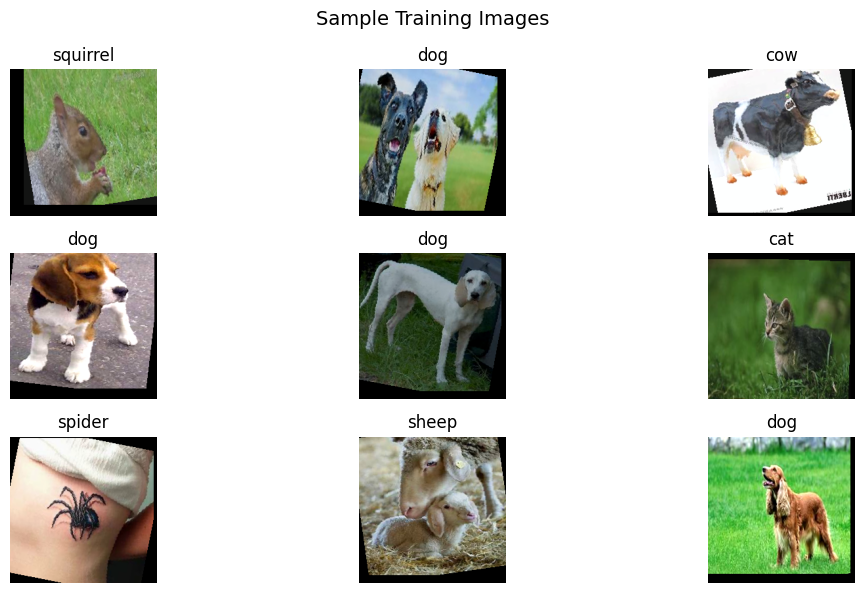

In [34]:
def imshow(img, title=''):
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = std * img + mean
    img  = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')

images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 6))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    imshow(images[i], title=class_names[labels[i]])
plt.suptitle('Sample Training Images', fontsize=14)
plt.tight_layout()
plt.show()

In [35]:
model = models.efficientnet_b2(weights=models.EfficientNet_B2_Weights.DEFAULT)

# PHASE 1 — freeze all base layers
for param in model.parameters():
    param.requires_grad = False

in_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.BatchNorm1d(in_features),
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, NUM_CLASSES)
)

model = model.to(device)

print("Model ready!")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Model ready!
Trainable parameters: 366,090


In [36]:
def train_model(model, train_loader, val_loader, optimizer, criterion, epochs, phase_name):

    train_acc_list = []
    val_acc_list   = []

    for epoch in range(epochs):
        model.train()
        correct = 0
        total   = 0
        running_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted  = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total   += labels.size(0)

        train_acc = correct / total

        model.eval()
        correct = 0
        total   = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                correct += (predicted == labels).sum().item()
                total   += labels.size(0)

        val_acc = correct / total

        train_acc_list.append(train_acc)
        val_acc_list.append(val_acc)

        print(f"[{phase_name}] Epoch {epoch+1}/{epochs}  "
              f"Loss: {running_loss/len(train_loader):.4f}  "
              f"Train Acc: {train_acc*100:.2f}%  "
              f"Val Acc: {val_acc*100:.2f}%")

    return train_acc_list, val_acc_list

In [ ]:
criterion  = nn.CrossEntropyLoss()

optimizer1 = optim.Adam(model.classifier.parameters(), lr=PHASE1_LR)

print("=== PHASE 1: Training head only (base frozen) ===")
train_acc1, val_acc1 = train_model(
    model, train_loader, val_loader,
    optimizer1, criterion,
    epochs=PHASE1_EPOCHS,
    phase_name='Phase 1'
)

=== PHASE 1: Training head only (base frozen) ===
[Phase 1] Epoch 1/5  Loss: 0.3509  Train Acc: 89.20%  Val Acc: 93.98%
[Phase 1] Epoch 2/5  Loss: 0.2660  Train Acc: 91.62%  Val Acc: 94.44%
[Phase 1] Epoch 3/5  Loss: 0.2534  Train Acc: 91.94%  Val Acc: 94.79%
[Phase 1] Epoch 4/5  Loss: 0.2466  Train Acc: 92.14%  Val Acc: 95.13%
[Phase 1] Epoch 5/5  Loss: 0.2321  Train Acc: 92.66%  Val Acc: 94.63%


In [ ]:
PHASE2_EPOCHS = 10
BATCH_SIZE    = 64

for param in model.parameters():
    param.requires_grad = False

for param in model.features[-3:].parameters():
    param.requires_grad = True

for param in model.classifier.parameters():
    param.requires_grad = True

optimizer2 = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=PHASE2_LR
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer2, mode='max', patience=3, factor=0.3
)

print("=== PHASE 2: Partial fine-tuning (last 3 blocks) ===")
print(f"Epochs: {PHASE2_EPOCHS}  |  LR: {PHASE2_LR}\n")

train_acc2, val_acc2 = train_model(
    model, train_loader, val_loader,
    optimizer2, criterion,
    epochs=PHASE2_EPOCHS,
    phase_name='Phase 2'
)

print(f"\nPhase 2 done! Best Val Acc: {max(val_acc2)*100:.2f}%")

=== PHASE 2: Partial fine-tuning (last 3 blocks) ===
Epochs: 10  |  LR: 0.0001

[Phase 2] Epoch 1/10  Loss: 0.1868  Train Acc: 94.20%  Val Acc: 97.04%
[Phase 2] Epoch 2/10  Loss: 0.1097  Train Acc: 96.50%  Val Acc: 97.48%
[Phase 2] Epoch 3/10  Loss: 0.0857  Train Acc: 97.24%  Val Acc: 97.59%
[Phase 2] Epoch 4/10  Loss: 0.0741  Train Acc: 97.54%  Val Acc: 97.57%
[Phase 2] Epoch 5/10  Loss: 0.0587  Train Acc: 98.01%  Val Acc: 97.69%
[Phase 2] Epoch 6/10  Loss: 0.0568  Train Acc: 98.23%  Val Acc: 97.75%
[Phase 2] Epoch 7/10  Loss: 0.0452  Train Acc: 98.60%  Val Acc: 97.80%
[Phase 2] Epoch 8/10  Loss: 0.0439  Train Acc: 98.52%  Val Acc: 97.88%
[Phase 2] Epoch 9/10  Loss: 0.0363  Train Acc: 98.80%  Val Acc: 97.88%
[Phase 2] Epoch 10/10  Loss: 0.0374  Train Acc: 98.80%  Val Acc: 97.71%

Phase 2 done! Best Val Acc: 97.88%


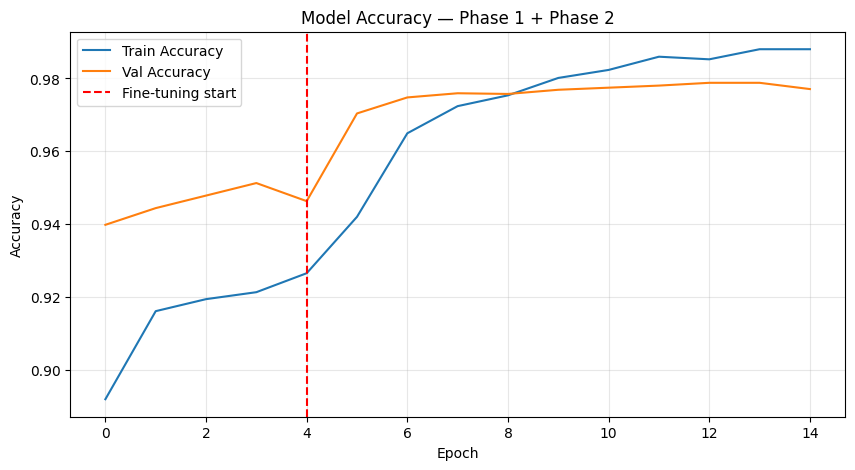

In [27]:
all_train_acc = train_acc1 + train_acc2
all_val_acc   = val_acc1   + val_acc2

plt.figure(figsize=(10, 5))

plt.plot(all_train_acc, label='Train Accuracy')
plt.plot(all_val_acc,   label='Val Accuracy')

plt.axvline(PHASE1_EPOCHS - 1, color='red', linestyle='--', label='Fine-tuning start')

plt.title('Model Accuracy — Phase 1 + Phase 2')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [21]:
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())

accuracy  = np.mean(np.array(y_true) == np.array(y_pred))
precision = precision_score(y_true, y_pred, average='weighted')
f1        = f1_score(y_true, y_pred, average='weighted')

print(f"Validation Accuracy  : {accuracy*100:.2f}%")
print(f"Precision Score      : {precision:.4f}")
print(f"F1 Score             : {f1:.4f}")

Validation Accuracy  : 97.71%
Precision Score      : 0.9772
F1 Score             : 0.9771


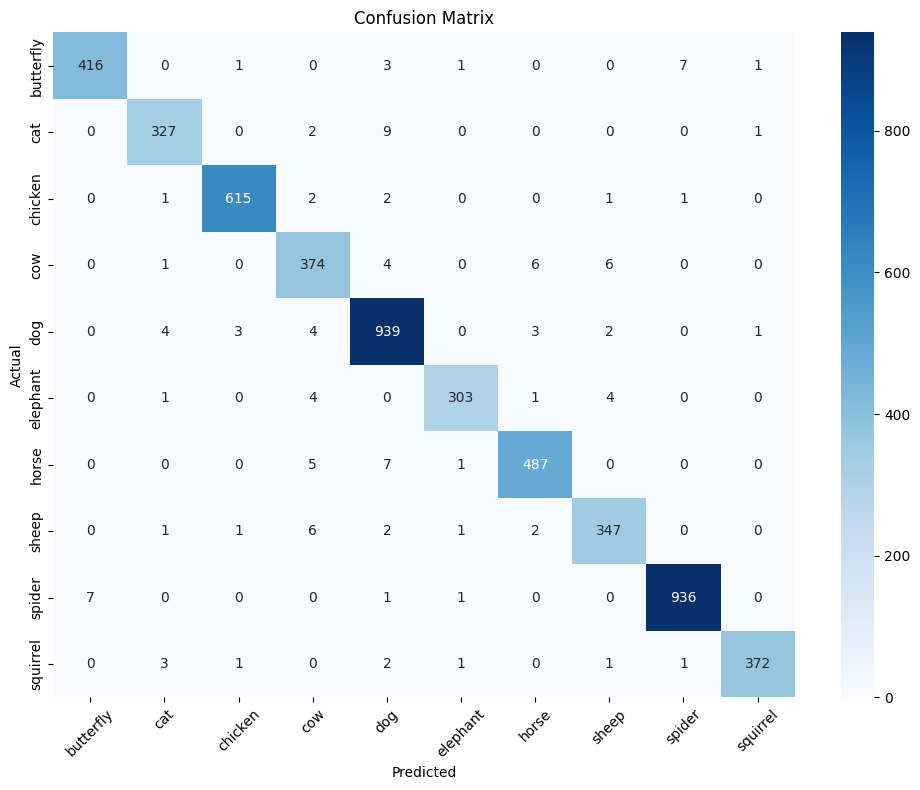

In [22]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

   butterfly       0.98      0.97      0.98       429
         cat       0.97      0.96      0.97       339
     chicken       0.99      0.99      0.99       622
         cow       0.94      0.96      0.95       391
         dog       0.97      0.98      0.98       956
    elephant       0.98      0.97      0.98       313
       horse       0.98      0.97      0.97       500
       sheep       0.96      0.96      0.96       360
      spider       0.99      0.99      0.99       945
    squirrel       0.99      0.98      0.98       381

    accuracy                           0.98      5236
   macro avg       0.98      0.97      0.97      5236
weighted avg       0.98      0.98      0.98      5236



In [24]:
torch.save(model.state_dict(), 'animal_classifier.pth')
print("Model saved as animal_classifier.pth")

Model saved as animal_classifier.pth


In [26]:
from PIL import Image

def predict_image(image_path, model, class_names):

    img = Image.open(image_path).convert('RGB')

    transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

    img_tensor = transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(img_tensor)
        probabilities = torch.softmax(outputs, dim=1)[0]
        predicted_idx = torch.argmax(probabilities).item()

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f"Predicted: {class_names[predicted_idx]}\n"
              f"Confidence: {probabilities[predicted_idx]*100:.2f}%")
    plt.axis('off')
    plt.show()

